## Existing Figures

The latest generated figures are also saved in the project outputs folder and can be viewed directly here:

![District price trends](../outputs/fig1_district_price_trends.png)

![Residual diagnostics](../outputs/fig2_residual_diagnostics.png)

# Lisbon Housing Prices: Shared Baseline Model

This notebook reproduces the shared district-quarter baseline model for the Lisbon housing-prices project. The project has four subtopics: immigration, foreign investment, infrastructure, and supply constraints.

Run the cells from top to bottom. The analysis code is intentionally visible and editable.

## 1. Environment Setup

This cell defines paths relative to the project folder. If the notebook is opened from this project, these paths should work without changes.

In [1]:
from pathlib import Path

# The notebook lives in notebooks/, so the project root is one folder above it.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "clean" / "district_quarter_full_dataset.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input file: {DATA_PATH}")
print(f"Outputs folder: {OUTPUT_DIR}")

Project root: /Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline
Input file: /Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/data/clean/district_quarter_full_dataset.csv
Outputs folder: /Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/outputs


## 2. Import Libraries

These are the libraries used for data handling, fixed-effects models, and figures.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS, PooledOLS

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 3. Configure Reproducibility

The model itself is deterministic, but setting a seed makes any later random extensions repeatable.

In [3]:
RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)
print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 2026


## 4. Load or Create Input Data

The clean dataset is already merged at district-quarter level. This notebook uses it directly instead of rebuilding the panel from older source files.

In [4]:
raw_data = pd.read_csv(DATA_PATH, parse_dates=["date"])

column_mapping = {
    "log_price_sale": "log_price",
    "ine_transaction_count_national": "transaction_count",
    "ine_transaction_value_thousands_national": "transaction_value_thousands",
    "ine_price_value_index_national": "value_index",
    "ine_volume_index_national": "volume_index",
    "mortgage_rate_fixed_pct_national": "mortgage_rate_fixed",
    "fdi_realestate_transactions_meur_national": "fdi_real_estate_transactions_meur",
}

panel_data = raw_data.rename(columns=column_mapping).copy()
panel_data["quarter"] = panel_data["date"].dt.to_period("Q")
panel_data = panel_data.sort_values(["district", "quarter"])
panel_data["price_growth_qoq"] = panel_data.groupby("district")["log_price"].diff()
panel_data["price_growth_yoy"] = panel_data.groupby("district")["log_price"].diff(4)
panel_data["log_price_lag1"] = panel_data.groupby("district")["log_price"].shift(1)

panel_data["qdate"] = panel_data["quarter"].dt.to_timestamp()
panel_data["t"] = panel_data["quarter"].astype(int)
panel_data["t"] = panel_data["t"] - panel_data["t"].min()

print(f"Loaded {len(panel_data):,} district-quarter rows")

Loaded 820 district-quarter rows


## 5. Inspect Data

Before estimating anything, inspect the dimensions, columns, date range, districts, and missing values.

In [5]:
print("Shape:", panel_data.shape)
print("Districts:", panel_data["district"].nunique())
print("Date range:", panel_data["date"].min().date(), "to", panel_data["date"].max().date())
print("\nFirst five rows:")
display(panel_data.head())

print("\nMissing values in model variables:")
model_columns = ["log_price", "volume_index", "fdi_real_estate_transactions_meur", "mortgage_rate_fixed"]
display(panel_data[model_columns].isna().sum().to_frame("missing_rows"))

Shape: (820, 24)
Districts: 20
Date range: 2015-01-01 to 2025-01-01

First five rows:


,district,period,year,quarter,date,price_sqm_sale,price_sqm_rental,log_price,price_growth_qoq,price_growth_yoy,transaction_count,transaction_value_thousands,value_index,volume_index,mortgage_rate_fixed,fdi_real_estate_transactions_meur,fdi_realestate_stock_meur_national,fdi_total_stock_meur_national,construction_cost_yoy_growth_pct_national,population_national,unemployment_rate_pct_regional,log_price_lag1,qdate,t
0,aveiro,1T2015,2015,2015Q1,2015-01-01,782.666667,3.700000,6.662707,NaN,NaN,21762.0,2662680.0,101.193890,96.176071,NaN,319.12,12554.79,125514.70,0.700000,10381838.0,14.2,NaN,2015-01-01,0
1,aveiro,2T2015,2015,2015Q2,2015-04-01,789.000000,3.766667,6.670766,0.008059,NaN,20614.0,2509888.0,100.699240,91.102542,NaN,297.14,12851.93,125514.70,0.833333,10381838.0,12.4,6.662707,2015-04-01,1
2,aveiro,3T2015,2015,2015Q3,2015-07-01,825.000000,3.933333,6.715383,0.044617,NaN,22928.0,2697752.0,97.312800,101.329150,NaN,319.68,13171.62,125514.70,1.133333,10381838.0,12.3,6.670766,2015-07-01,2
3,aveiro,4T2015,2015,2015Q4,2015-10-01,823.333333,3.900000,6.713361,-0.002022,NaN,25205.0,3071762.0,100.794070,111.392237,NaN,405.34,13576.96,125514.70,1.200000,10381838.0,12.5,6.715383,2015-10-01,3
4,aveiro,1T2016,2016,2016Q1,2016-01-01,804.666667,4.000000,6.690428,-0.022933,0.027721,24926.0,3001077.0,99.576915,110.159211,NaN,434.90,14011.86,127838.92,1.366667,10356516.0,12.8,6.713361,2016-01-01,4



Missing values in model variables:


,missing_rows
log_price,0
volume_index,0
fdi_real_estate_transactions_meur,0
mortgage_rate_fixed,300


## 6. Run Core Processing

The next cell puts the data into the two-level panel format required by `linearmodels`. It then estimates the six baseline specifications used in the project. The fourth specification is expected to fail because national variables are perfectly collinear with quarter fixed effects.

In [6]:
def r2_rmse(result, y):
    residuals = result.resids.values
    sse = np.sum(residuals ** 2)
    sst = np.sum((y.values - y.values.mean()) ** 2)
    return 1 - sse / sst, np.sqrt(np.mean(residuals ** 2))


def run_all_specs(panel):
    results = {}

    pooled_model = PooledOLS.from_formula(
        "log_price ~ 1 + t + volume_index + fdi_real_estate_transactions_meur",
        data=panel,
    )
    pooled_result = pooled_model.fit(cov_type="clustered", cluster_entity=True)
    results["0_pooled_ols"] = (pooled_result, *r2_rmse(pooled_result, panel["log_price"]))

    entity_model = PanelOLS.from_formula("log_price ~ 1 + EntityEffects", data=panel)
    entity_result = entity_model.fit(cov_type="clustered", cluster_entity=True)
    results["0b_entity_fe_only"] = (entity_result, *r2_rmse(entity_result, panel["log_price"]))

    twfe_model = PanelOLS.from_formula("log_price ~ 1 + EntityEffects + TimeEffects", data=panel)
    twfe_result = twfe_model.fit(cov_type="clustered", cluster_entity=True)
    results["1_twfe_decomposition"] = (twfe_result, *r2_rmse(twfe_result, panel["log_price"]))

    trend_model = PanelOLS.from_formula(
        "log_price ~ 1 + t + volume_index + fdi_real_estate_transactions_meur + EntityEffects",
        data=panel,
    )
    trend_result = trend_model.fit(cov_type="clustered", cluster_entity=True)
    results["2_entity_fe_trend_covars"] = (trend_result, *r2_rmse(trend_result, panel["log_price"]))

    mortgage_panel = panel.dropna(subset=["mortgage_rate_fixed"])
    mortgage_model = PanelOLS.from_formula(
        "log_price ~ 1 + t + mortgage_rate_fixed + volume_index + "
        "fdi_real_estate_transactions_meur + EntityEffects",
        data=mortgage_panel,
    )
    mortgage_result = mortgage_model.fit(cov_type="clustered", cluster_entity=True)
    results["3_entity_fe_trend_mortgage_restricted"] = (
        mortgage_result,
        *r2_rmse(mortgage_result, mortgage_panel["log_price"]),
    )

    spec4_error = None
    try:
        full_twfe_model = PanelOLS.from_formula(
            "log_price ~ 1 + mortgage_rate_fixed + volume_index + "
            "fdi_real_estate_transactions_meur + EntityEffects + TimeEffects",
            data=mortgage_panel,
        )
        full_twfe_result = full_twfe_model.fit(cov_type="clustered", cluster_entity=True)
        results["4_full_twfe_with_covars"] = (
            full_twfe_result,
            *r2_rmse(full_twfe_result, mortgage_panel["log_price"]),
        )
    except Exception as error:
        spec4_error = str(error)

    growth_panel = panel.dropna(subset=["price_growth_qoq"])
    growth_model = PanelOLS.from_formula(
        "price_growth_qoq ~ 1 + log_price_lag1 + volume_index + "
        "fdi_real_estate_transactions_meur + EntityEffects",
        data=growth_panel,
    )
    growth_result = growth_model.fit(cov_type="clustered", cluster_entity=True)
    results["5_growth_convergence"] = (growth_result, *r2_rmse(growth_result, growth_panel["price_growth_qoq"]))

    return results, spec4_error


panel = panel_data.set_index(["district", "qdate"])
panel.index = panel.index.set_names(["district", "quarter"])
results, spec4_error = run_all_specs(panel)

summary_rows = []
for name, (result, r2_total, rmse) in results.items():
    summary_rows.append({
        "spec": name,
        "n_obs": int(result.nobs),
        "r2_total": round(r2_total, 4),
        "r2_within": round(result.rsquared_within, 4),
        "rmse": round(rmse, 4),
    })

summary = pd.DataFrame(summary_rows)
display(summary)
print("Spec 4 failed as expected:" if spec4_error else "Spec 4 unexpectedly succeeded")

/Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/.venv/lib/python3.9/site-packages/linearmodels/panel/model.py:1072: RuntimeWarning: divide by zero encountered in matmul
  weps = wy - wx @ params
/Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/.venv/lib/python3.9/site-packages/linearmodels/panel/model.py:1072: RuntimeWarning: overflow encountered in matmul
  weps = wy - wx @ params
/Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/.venv/lib/python3.9/site-packages/linearmodels/panel/model.py:1072: RuntimeWarning: invalid value encountered in matmul
  weps = wy - wx @ params
/Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/.venv/lib/python3.9/site-packages/linearmodels/panel/model.py:1074: RuntimeWarning: divide by zero encountered in matmul
  fitted = DataFrame(x @ params, index, ["fitted_values"])
/Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipel

,spec,n_obs,r2_total,r2_within,rmse
0,0_pooled_ols,820,0.1990,0.7225,0.3868
1,0b_entity_fe_only,820,0.7246,0.0000,0.2268
2,1_twfe_decomposition,820,0.9267,0.0000,0.1170
3,2_entity_fe_trend_covars,820,0.9236,0.7225,0.1195
4,3_entity_fe_trend_mortgage_restricted,520,0.9777,0.8289,0.0689
5,5_growth_convergence,800,0.1195,0.0593,0.0267


Spec 4 failed as expected:


## 7. Validate Results

These checks confirm that the panel has the expected size and that the model results contain finite summary statistics.

In [7]:
assert len(panel) == 820, f"Expected 820 rows, found {len(panel)}"
assert panel.index.get_level_values("district").nunique() == 20
assert summary["n_obs"].notna().all()
assert np.isfinite(summary[["r2_total", "rmse"]].to_numpy()).all()

print("Validation passed.")
print(f"Panel rows: {len(panel):,}")
print(f"Districts: {panel.index.get_level_values('district').nunique()}")
print(f"Estimated specifications: {len(results)}")

Validation passed.
Panel rows: 820
Districts: 20
Estimated specifications: 6


## 8. Save Outputs

This cell writes the panel, model comparison table, coefficient tables, and two diagnostic figures to `outputs/`.

/Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/.venv/lib/python3.9/site-packages/linearmodels/panel/covariance.py:120: RuntimeWarning: divide by zero encountered in matmul
  return self._y - self._x @ self._params
/Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/.venv/lib/python3.9/site-packages/linearmodels/panel/covariance.py:120: RuntimeWarning: overflow encountered in matmul
  return self._y - self._x @ self._params
/Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/.venv/lib/python3.9/site-packages/linearmodels/panel/covariance.py:120: RuntimeWarning: invalid value encountered in matmul
  return self._y - self._x @ self._params


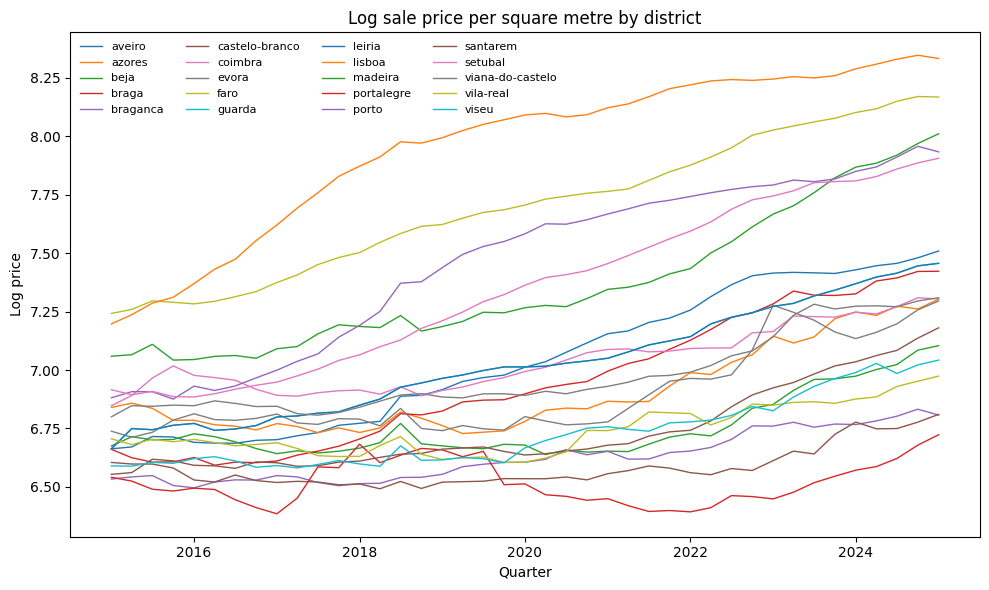

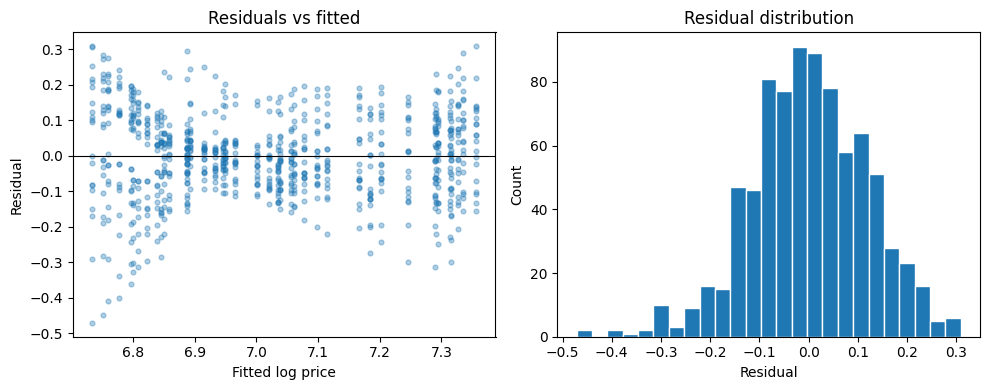

Saved tables and figures to: /Users/carolinapainvin/Desktop/Master Thesis/lisbon_housing_baseline_pipeline/outputs


In [8]:
panel.to_csv(OUTPUT_DIR / "district_quarter_panel_final.csv")
summary.to_csv(OUTPUT_DIR / "model_comparison_table.csv", index=False)

coefficient_specs = [
    "2_entity_fe_trend_covars",
    "3_entity_fe_trend_mortgage_restricted",
    "5_growth_convergence",
]

for name in coefficient_specs:
    result = results[name][0]
    coefficient_table = pd.DataFrame({
        "param": result.params.index,
        "coef": result.params.values,
        "std_err": result.std_errors.values,
        "t_stat": result.tstats.values,
        "p_value": result.pvalues.values,
    })
    coefficient_table.to_csv(OUTPUT_DIR / f"coefs_{name}.csv", index=False)

plot_panel = panel.drop(columns=["quarter"]).reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
for district, group in plot_panel.groupby("district"):
    ax.plot(group["quarter"], group["log_price"], linewidth=1, label=district)
ax.set_title("Log sale price per square metre by district")
ax.set_xlabel("Quarter")
ax.set_ylabel("Log price")
ax.legend(ncol=4, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_district_price_trends.png", dpi=180)
plt.show()
plt.close(fig)

trend_result = results["2_entity_fe_trend_covars"][0]
residuals = trend_result.resids
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(trend_result.fitted_values.iloc[:, 0], residuals, alpha=0.35, s=12)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(xlabel="Fitted log price", ylabel="Residual", title="Residuals vs fitted")
axes[1].hist(residuals, bins=25, edgecolor="white")
axes[1].set(xlabel="Residual", ylabel="Count", title="Residual distribution")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig2_residual_diagnostics.png", dpi=180)
plt.show()
plt.close(fig)

print("Saved tables and figures to:", OUTPUT_DIR)

## 9. Quick Re-run Cell

After editing and rerunning earlier cells, use this final check to confirm that the expected output files exist.

In [9]:
expected_outputs = [
    "district_quarter_panel_final.csv",
    "model_comparison_table.csv",
    "coefs_2_entity_fe_trend_covars.csv",
    "coefs_3_entity_fe_trend_mortgage_restricted.csv",
    "coefs_5_growth_convergence.csv",
    "fig1_district_price_trends.png",
    "fig2_residual_diagnostics.png",
]

missing_outputs = [name for name in expected_outputs if not (OUTPUT_DIR / name).exists()]
assert not missing_outputs, f"Missing outputs: {missing_outputs}"
print(f"Complete: {len(expected_outputs)} output files are present.")

Complete: 7 output files are present.
